# Experiments

## Objective

This notebook extends the existing EDA and modeling workflow
with additional experiments requested during project review.

The experiments focus on:

1. One-feature-at-a-time evaluation
2. Feature-group ablation
3. Pearson correlation comparison
4. Fairness and subgroup error analysis
5. Fairness-aware XGBoost
6. PyTorch tabular neural network
7. Comparison with existing baseline models
8. Review of comparable student-dropout solutions

## Experimental Boundary

The previously observed test set will not be used for selecting or comparing
these new experiments.

All exploratory experiments will use the training and evaluation partitions
only.

The existing final test result remains unchanged.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm torch fairlearn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import sklearn
import xgboost
import torch
import fairlearn

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("PyTorch:", torch.__version__)
print("Fairlearn:", fairlearn.__version__)

scikit-learn: 1.9.0
XGBoost: 3.3.0
PyTorch: 2.13.0+cpu
Fairlearn: 0.14.0


Load final modeling dataset

In [5]:
df = pd.read_csv("final_modeling_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())
print(df.info())

Dataset shape: (32593, 49)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,quiz,repeatactivity,resource,sharedsubpage,subpage,url,course_duration,number_of_early_assessments,average_early_assessment_weight,early_assessment_workload
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.0,9.0,0.0,23.0,1.0,268,701.0,14.878745,10430.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.0,5.0,0.0,62.0,33.0,268,701.0,14.878745,10430.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,4.0,0.0,22.0,4.0,268,701.0,14.878745,10430.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.0,10.0,0.0,78.0,39.0,268,701.0,14.878745,10430.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.0,7.0,0.0,29.0,6.0,268,701.0,14.878745,10430.0


<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   code_module                      32593 non-null  str    
 1   code_presentation                32593 non-null  str    
 2   id_student                       32593 non-null  int64  
 3   gender                           32593 non-null  str    
 4   region                           32593 non-null  str    
 5   highest_education                32593 non-null  str    
 6   imd_band                         31482 non-null  str    
 7   age_band                         32593 non-null  str    
 8   num_of_prev_attempts             32593 non-null  int64  
 9   studied_credits                  32593 non-null  int64  
 10  disability                       32593 non-null  str    
 11  dropout_target                   32593 non-null  int64  
 12  assessment_count             

Verify target

In [6]:
print("Target distribution:")
print(df["dropout_target"].value_counts())

print("\nTarget percentage:")
print(
    df["dropout_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
dropout_target
0    22437
1    10156
Name: count, dtype: int64

Target percentage:
dropout_target
0    68.84
1    31.16
Name: proportion, dtype: float64


Verify leakage

In [8]:
LEAKAGE_COLUMNS = [
    "final_result",
    "date_unregistration"
]

existing_leakage = [
    col for col in LEAKAGE_COLUMNS
    if col in df.columns
]

print("Potential leakage columns found:")
print(existing_leakage)

df_model = df.drop(
    columns=existing_leakage,
    errors="ignore"
).copy()

print("Shape after leakage removal:", df_model.shape)

Potential leakage columns found:
[]
Shape after leakage removal: (32593, 49)


Define X and y

In [9]:
TARGET = "dropout_target"

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32593, 48)
y shape: (32593,)


### Pearson Correlation Analysis

Pearson correlation is used to examine the linear relationship between
numeric predictors and the dropout target.

This analysis is exploratory and does not establish causation.

Correlation will later be compared with the one-feature-at-a-time
modeling experiment.

In [10]:
# Select numeric columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("\nNumeric features:")
print(numeric_features)

Number of numeric features: 40

Numeric features:
['id_student', 'num_of_prev_attempts', 'studied_credits', 'assessment_count', 'avg_assessment_score', 'max_assessment_score', 'min_assessment_score', 'weighted_assessment_score', 'late_submission_count', 'date_registration', 'registration_days_before_start', 'late_registration', 'total_clicks', 'active_learning_days', 'distinct_resources', 'resource_diversity', 'average_daily_clicks', 'dataplus', 'dualpane', 'externalquiz', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent', 'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'repeatactivity', 'resource', 'sharedsubpage', 'subpage', 'url', 'course_duration', 'number_of_early_assessments', 'average_early_assessment_weight', 'early_assessment_workload']


In [11]:
# Create correlation table with the target
correlation_df = (
    df_model[numeric_features + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

print("Correlation of numeric features with dropout:")
display(correlation_df.to_frame(name="pearson_correlation"))

Correlation of numeric features with dropout:


,pearson_correlation
max_assessment_score,-0.273943
active_learning_days,-0.257157
avg_assessment_score,-0.246256
weighted_assessment_score,-0.239883
studied_credits,0.191191
min_assessment_score,-0.184436
total_clicks,-0.180901
distinct_resources,-0.178760
resource_diversity,-0.168731
homepage,-0.160127


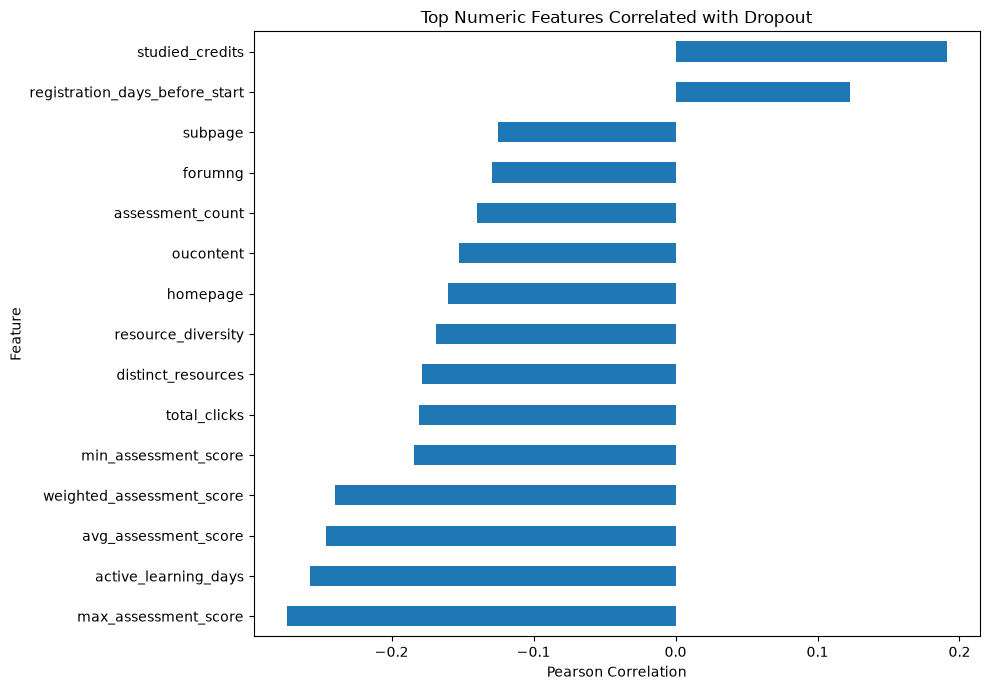

In [12]:
# Select the 15 strongest correlations
top_corr = correlation_df.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_corr.plot(kind="barh")

plt.title("Top Numeric Features Correlated with Dropout")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

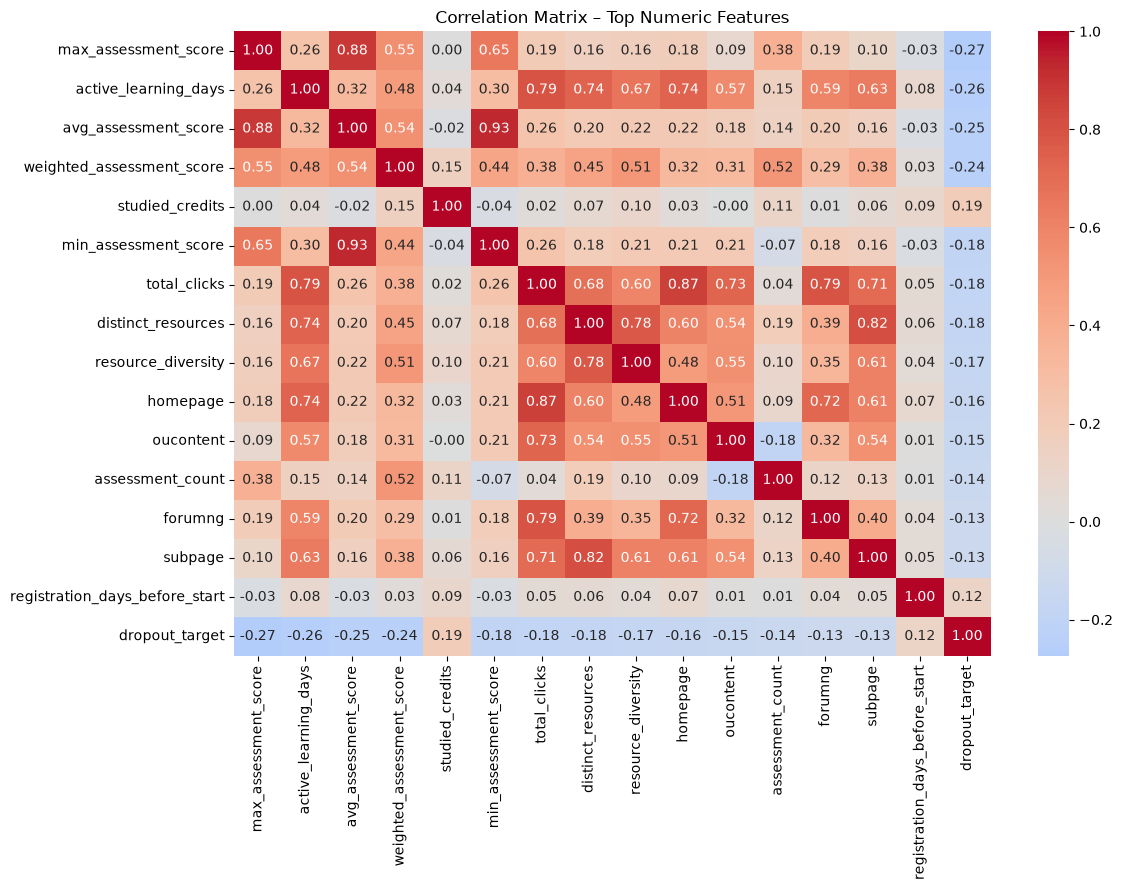

In [13]:
# Top correlated numeric features
top_features = correlation_df.head(15).index.tolist()

corr_matrix = df_model[top_features + [TARGET]].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix – Top Numeric Features")
plt.tight_layout()

plt.show()

In [14]:
# Correlation between predictors
feature_corr = X[numeric_features].corr().abs()

# Keep only upper triangle
upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

# Find pairs with correlation >= 0.80
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Absolute_Correlation"]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["Absolute_Correlation"] >= 0.80
    ]
    .sort_values("Absolute_Correlation", ascending=False)
)

display(high_corr_pairs)

,Feature_1,Feature_2,Absolute_Correlation
370,date_registration,registration_days_before_start,1.000000
166,avg_assessment_score,min_assessment_score,0.927109
165,avg_assessment_score,max_assessment_score,0.881424
502,total_clicks,homepage,0.865560
594,distinct_resources,subpage,0.818450


### Pearson Correlation – Interpretation

Pearson correlation was used to identify linear relationships between
numeric predictors and the dropout target.

The strongest relationships should be compared with the later
one-feature-at-a-time modeling experiment.

Correlation alone should not be used to select the final model features
because it cannot capture nonlinear relationships and cannot directly
evaluate categorical predictors.

##############################################################################

## One-Feature-at-a-Time Evaluation

The existing training, evaluation, and test partitions created during
the previous modeling stage will be reused.

No new random split will be created.

The test partition will remain untouched and will not be used for
selecting or comparing the new exploratory experiments.

In [19]:
import joblib

X_train = joblib.load("X_train.pkl")
X_eval = joblib.load("X_eval.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_eval = joblib.load("y_eval.pkl")
y_test = joblib.load("y_test.pkl")

print("Files loaded successfully!")

Files loaded successfully!


In [20]:
print("X_train:")
print(type(X_train), X_train.shape)

print("\nX_eval:")
print(type(X_eval), X_eval.shape)

print("\nX_test:")
print(type(X_test), X_test.shape)

print("\ny_train:")
print(type(y_train), y_train.shape)

print("\ny_eval:")
print(type(y_eval), y_eval.shape)

print("\ny_test:")
print(type(y_test), y_test.shape)

X_train:
<class 'numpy.ndarray'> (22815, 85)

X_eval:
<class 'numpy.ndarray'> (4889, 85)

X_test:
<class 'numpy.ndarray'> (4889, 85)

y_train:
<class 'pandas.Series'> (22815,)

y_eval:
<class 'pandas.Series'> (4889,)

y_test:
<class 'pandas.Series'> (4889,)


In [23]:
print("X_train type:", type(X_train))
print("X_train shape:", X_train.shape)

print("\nX_eval type:", type(X_eval))
print("X_eval shape:", X_eval.shape)

print("\nX_test type:", type(X_test))
print("X_test shape:", X_test.shape)

X_train type: <class 'numpy.ndarray'>
X_train shape: (22815, 85)

X_eval type: <class 'numpy.ndarray'>
X_eval shape: (4889, 85)

X_test type: <class 'numpy.ndarray'>
X_test shape: (4889, 85)


In [24]:
print(X_train[:5])
display(
    pd.DataFrame(X_train[:5])
)

[[-0.33896087  0.98007567 -0.06266419  0.18841316  0.17164402  0.11139275
   0.22630569 -0.63618053 -0.92201409  0.92201409 -0.08587036 -0.29853292
  -0.17848658 -0.2410398  -0.21197484 -0.20082326 -0.0516637  -0.213381
  -0.21719009 -0.28305713 -0.10222595 -0.25110708 -0.20750711 -0.36267246
  -0.38427726 -0.15844245 -0.37101737 -0.34008851 -0.30129624 -0.35923597
  -0.00926908 -0.15164165 -0.04671952 -0.33080456 -0.27330798  0.97960487
   1.49714568 -0.86806042  0.134891    0.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          1.          0.          1.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          1.          0.          0.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          1.
   0.        ]
 [ 1.72053105  

,0,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,84
0,-0.338961,0.980076,-0.062664,0.188413,0.171644,0.111393,0.226306,-0.636181,-0.922014,0.922014,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.720531,0.980076,-0.062664,1.356184,0.879676,1.514571,1.643435,-0.636181,0.918122,-0.918122,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.720531,1.711354,-0.062664,0.188413,0.171644,0.111393,0.226306,-0.636181,-1.771308,1.771308,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.720531,-0.482481,-1.505332,-2.601262,-3.046681,-1.777501,-1.770332,-0.636181,-0.072720,0.072720,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.338961,0.980076,1.380003,0.923676,0.815309,0.920919,1.401974,-0.636181,1.079893,-1.079893,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [27]:
preprocessor = joblib.load("preprocessor.pkl")

print("\nPreprocessor type:")
print(type(preprocessor))

print("\nPreprocessor:")
print(preprocessor)


Preprocessor type:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['num_of_prev_attempts', 'studied_credits',
                                  'assessment_count', 'avg_assessment_score',
                                  'max_assessment_score',
                                  'min_assessment_score',
                                  'weighted_assessment_score',
                                  'late_submission_count', 'date_registration',
                                  'registration_days...
                                  'forumng', 'glossary', 'homepage',
                                  'htmlactivity', 'oucollaborate', 'oucontent',
               

Count the encoded columns

In [28]:
feature_names_encoded = preprocessor.get_feature_names_out()

print("Number of encoded features:",
      len(feature_names_encoded))

print("\nFirst 30 encoded features:")

for i, name in enumerate(feature_names_encoded[:30]):
    print(i, "->", name)

Number of encoded features: 85

First 30 encoded features:
0 -> num__num_of_prev_attempts
1 -> num__studied_credits
2 -> num__assessment_count
3 -> num__avg_assessment_score
4 -> num__max_assessment_score
5 -> num__min_assessment_score
6 -> num__weighted_assessment_score
7 -> num__late_submission_count
8 -> num__date_registration
9 -> num__registration_days_before_start
10 -> num__late_registration
11 -> num__total_clicks
12 -> num__active_learning_days
13 -> num__distinct_resources
14 -> num__resource_diversity
15 -> num__average_daily_clicks
16 -> num__dataplus
17 -> num__dualpane
18 -> num__externalquiz
19 -> num__forumng
20 -> num__glossary
21 -> num__homepage
22 -> num__htmlactivity
23 -> num__oucollaborate
24 -> num__oucontent
25 -> num__ouelluminate
26 -> num__ouwiki
27 -> num__page
28 -> num__questionnaire
29 -> num__quiz


In [30]:
print("X_train shape:", X_train.shape)
print("X_eval shape:", X_eval.shape)
print("X_test shape:", X_test.shape)

feature_names_encoded = preprocessor.get_feature_names_out()

print("\nEncoded feature count:", len(feature_names_encoded))

for i, name in enumerate(feature_names_encoded[:40]):
    print(i, "->", name)

X_train shape: (22815, 85)
X_eval shape: (4889, 85)
X_test shape: (4889, 85)

Encoded feature count: 85
0 -> num__num_of_prev_attempts
1 -> num__studied_credits
2 -> num__assessment_count
3 -> num__avg_assessment_score
4 -> num__max_assessment_score
5 -> num__min_assessment_score
6 -> num__weighted_assessment_score
7 -> num__late_submission_count
8 -> num__date_registration
9 -> num__registration_days_before_start
10 -> num__late_registration
11 -> num__total_clicks
12 -> num__active_learning_days
13 -> num__distinct_resources
14 -> num__resource_diversity
15 -> num__average_daily_clicks
16 -> num__dataplus
17 -> num__dualpane
18 -> num__externalquiz
19 -> num__forumng
20 -> num__glossary
21 -> num__homepage
22 -> num__htmlactivity
23 -> num__oucollaborate
24 -> num__oucontent
25 -> num__ouelluminate
26 -> num__ouwiki
27 -> num__page
28 -> num__questionnaire
29 -> num__quiz
30 -> num__repeatactivity
31 -> num__resource
32 -> num__sharedsubpage
33 -> num__subpage
34 -> num__url
35 -> nu

Create the encoded feature names

In [31]:
feature_names_encoded = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(feature_names_encoded))

Number of encoded features: 85


Separate numeric and categorical encoded features

In [32]:
numeric_encoded_features = [
    name for name in feature_names_encoded
    if name.startswith("num__")
]

categorical_encoded_features = [
    name for name in feature_names_encoded
    if name.startswith("cat__")
]

print("Numeric encoded features:",
      len(numeric_encoded_features))

print("Categorical encoded features:",
      len(categorical_encoded_features))

Numeric encoded features: 39
Categorical encoded features: 46


In [33]:
print("NUMERIC FEATURES")
print("=" * 50)

for i, feature in enumerate(numeric_encoded_features):
    print(i, "→", feature)

NUMERIC FEATURES
0 → num__num_of_prev_attempts
1 → num__studied_credits
2 → num__assessment_count
3 → num__avg_assessment_score
4 → num__max_assessment_score
5 → num__min_assessment_score
6 → num__weighted_assessment_score
7 → num__late_submission_count
8 → num__date_registration
9 → num__registration_days_before_start
10 → num__late_registration
11 → num__total_clicks
12 → num__active_learning_days
13 → num__distinct_resources
14 → num__resource_diversity
15 → num__average_daily_clicks
16 → num__dataplus
17 → num__dualpane
18 → num__externalquiz
19 → num__forumng
20 → num__glossary
21 → num__homepage
22 → num__htmlactivity
23 → num__oucollaborate
24 → num__oucontent
25 → num__ouelluminate
26 → num__ouwiki
27 → num__page
28 → num__questionnaire
29 → num__quiz
30 → num__repeatactivity
31 → num__resource
32 → num__sharedsubpage
33 → num__subpage
34 → num__url
35 → num__course_duration
36 → num__number_of_early_assessments
37 → num__average_early_assessment_weight
38 → num__early_assessme

In [34]:
print("\nCATEGORICAL FEATURES")
print("=" * 50)

for i, feature in enumerate(categorical_encoded_features):
    print(i, "→", feature)


CATEGORICAL FEATURES
0 → cat__code_module_AAA
1 → cat__code_module_BBB
2 → cat__code_module_CCC
3 → cat__code_module_DDD
4 → cat__code_module_EEE
5 → cat__code_module_FFF
6 → cat__code_module_GGG
7 → cat__code_presentation_2013B
8 → cat__code_presentation_2013J
9 → cat__code_presentation_2014B
10 → cat__code_presentation_2014J
11 → cat__gender_F
12 → cat__gender_M
13 → cat__region_East Anglian Region
14 → cat__region_East Midlands Region
15 → cat__region_Ireland
16 → cat__region_London Region
17 → cat__region_North Region
18 → cat__region_North Western Region
19 → cat__region_Scotland
20 → cat__region_South East Region
21 → cat__region_South Region
22 → cat__region_South West Region
23 → cat__region_Wales
24 → cat__region_West Midlands Region
25 → cat__region_Yorkshire Region
26 → cat__highest_education_A Level or Equivalent
27 → cat__highest_education_HE Qualification
28 → cat__highest_education_Lower Than A Level
29 → cat__highest_education_No Formal quals
30 → cat__highest_educatio

Create original-feature groups

In [35]:
# Raw numeric feature names
raw_numeric_features = [
    feature.replace("num__", "")
    for feature in numeric_encoded_features
]

print("Raw numeric features:")
print(raw_numeric_features)

Raw numeric features:
['num_of_prev_attempts', 'studied_credits', 'assessment_count', 'avg_assessment_score', 'max_assessment_score', 'min_assessment_score', 'weighted_assessment_score', 'late_submission_count', 'date_registration', 'registration_days_before_start', 'late_registration', 'total_clicks', 'active_learning_days', 'distinct_resources', 'resource_diversity', 'average_daily_clicks', 'dataplus', 'dualpane', 'externalquiz', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent', 'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'repeatactivity', 'resource', 'sharedsubpage', 'subpage', 'url', 'course_duration', 'number_of_early_assessments', 'average_early_assessment_weight', 'early_assessment_workload']


Get the categorical feature names

In [36]:
categorical_original_features = []

for transformer_name, transformer, columns in preprocessor.transformers_:
    if transformer_name == "cat":
        categorical_original_features = list(columns)

categorical_original_features

['code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'disability']

Create the complete raw-feature list

In [37]:
raw_features = (
    raw_numeric_features +
    categorical_original_features
)

print("Total raw features:", len(raw_features))

for i, feature in enumerate(raw_features, start=1):
    print(i, "→", feature)

Total raw features: 47
1 → num_of_prev_attempts
2 → studied_credits
3 → assessment_count
4 → avg_assessment_score
5 → max_assessment_score
6 → min_assessment_score
7 → weighted_assessment_score
8 → late_submission_count
9 → date_registration
10 → registration_days_before_start
11 → late_registration
12 → total_clicks
13 → active_learning_days
14 → distinct_resources
15 → resource_diversity
16 → average_daily_clicks
17 → dataplus
18 → dualpane
19 → externalquiz
20 → forumng
21 → glossary
22 → homepage
23 → htmlactivity
24 → oucollaborate
25 → oucontent
26 → ouelluminate
27 → ouwiki
28 → page
29 → questionnaire
30 → quiz
31 → repeatactivity
32 → resource
33 → sharedsubpage
34 → subpage
35 → url
36 → course_duration
37 → number_of_early_assessments
38 → average_early_assessment_weight
39 → early_assessment_workload
40 → code_module
41 → code_presentation
42 → gender
43 → region
44 → highest_education
45 → imd_band
46 → age_band
47 → disability


Create mapping from raw feature → encoded columns

In [38]:
feature_to_encoded_columns = {}

for raw_feature in raw_numeric_features:
    
    encoded_name = "num__" + raw_feature
    
    if encoded_name in feature_names_encoded:
        feature_to_encoded_columns[raw_feature] = [
            encoded_name
        ]


for raw_feature in categorical_original_features:
    
    prefix = "cat__" + raw_feature + "_"
    
    matching_columns = [
        name
        for name in feature_names_encoded
        if name.startswith(prefix)
    ]
    
    feature_to_encoded_columns[raw_feature] = matching_columns

In [39]:
for feature, encoded_columns in feature_to_encoded_columns.items():
    print(f"\n{feature}")
    print("   ", encoded_columns)


num_of_prev_attempts
    ['num__num_of_prev_attempts']

studied_credits
    ['num__studied_credits']

assessment_count
    ['num__assessment_count']

avg_assessment_score
    ['num__avg_assessment_score']

max_assessment_score
    ['num__max_assessment_score']

min_assessment_score
    ['num__min_assessment_score']

weighted_assessment_score
    ['num__weighted_assessment_score']

late_submission_count
    ['num__late_submission_count']

date_registration
    ['num__date_registration']

registration_days_before_start
    ['num__registration_days_before_start']

late_registration
    ['num__late_registration']

total_clicks
    ['num__total_clicks']

active_learning_days
    ['num__active_learning_days']

distinct_resources
    ['num__distinct_resources']

resource_diversity
    ['num__resource_diversity']

average_daily_clicks
    ['num__average_daily_clicks']

dataplus
    ['num__dataplus']

dualpane
    ['num__dualpane']

externalquiz
    ['num__externalquiz']

forumng
    ['num__fo

Check that all 85 columns are accounted for

In [40]:
mapped_columns = [
    column
    for columns in feature_to_encoded_columns.values()
    for column in columns
]

print("Encoded columns:", len(feature_names_encoded))
print("Mapped columns:", len(mapped_columns))
print(
    "All encoded columns mapped:",
    set(feature_names_encoded) == set(mapped_columns)
)

Encoded columns: 85
Mapped columns: 85
All encoded columns mapped: True


Convert feature names to column indexes

In [41]:
encoded_column_index = {
    feature: [
        list(feature_names_encoded).index(column)
        for column in encoded_columns
    ]
    for feature, encoded_columns
    in feature_to_encoded_columns.items()
}

In [42]:
for feature, indexes in encoded_column_index.items():
    print(feature, "→", indexes)

num_of_prev_attempts → [0]
studied_credits → [1]
assessment_count → [2]
avg_assessment_score → [3]
max_assessment_score → [4]
min_assessment_score → [5]
weighted_assessment_score → [6]
late_submission_count → [7]
date_registration → [8]
registration_days_before_start → [9]
late_registration → [10]
total_clicks → [11]
active_learning_days → [12]
distinct_resources → [13]
resource_diversity → [14]
average_daily_clicks → [15]
dataplus → [16]
dualpane → [17]
externalquiz → [18]
forumng → [19]
glossary → [20]
homepage → [21]
htmlactivity → [22]
oucollaborate → [23]
oucontent → [24]
ouelluminate → [25]
ouwiki → [26]
page → [27]
questionnaire → [28]
quiz → [29]
repeatactivity → [30]
resource → [31]
sharedsubpage → [32]
subpage → [33]
url → [34]
course_duration → [35]
number_of_early_assessments → [36]
average_early_assessment_weight → [37]
early_assessment_workload → [38]
code_module → [39, 40, 41, 42, 43, 44, 45]
code_presentation → [46, 47, 48, 49]
gender → [50, 51]
region → [52, 53, 54, 55

Create the HGB model

In [43]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [44]:
def create_hgb_model():
    return HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=200,
        random_state=42
    )

Create the metrics function

In [45]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [46]:
def calculate_metrics(y_true, probabilities, threshold=0.5):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),

        "pr_auc": average_precision_score(
            y_true,
            probabilities
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "fp": int(fp),
        "fn": int(fn)
    }

Use withdrawal weight 3.0

In [47]:
sample_weights_train = np.where(
    np.asarray(y_train) == 1,
    3.0,
    1.0
)

print(
    "Non-withdrawal weight:",
    1.0
)

print(
    "Withdrawal weight:",
    3.0
)

Non-withdrawal weight: 1.0
Withdrawal weight: 3.0


Evaluate ONE feature first

In [48]:
feature = "active_learning_days"

indexes = encoded_column_index[feature]

X_train_single = X_train[:, indexes]
X_eval_single = X_eval[:, indexes]

print("Feature:", feature)
print("Encoded columns:", indexes)
print("Training shape:", X_train_single.shape)
print("Evaluation shape:", X_eval_single.shape)

Feature: active_learning_days
Encoded columns: [12]
Training shape: (22815, 1)
Evaluation shape: (4889, 1)


Train the model

In [49]:
model = create_hgb_model()

model.fit(
    X_train_single,
    y_train,
    sample_weight=sample_weights_train
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [50]:
probabilities = model.predict_proba(
    X_eval_single
)[:, 1]

Calculate the result

In [51]:
result = calculate_metrics(
    y_eval,
    probabilities
)

result["feature"] = feature

result

{'roc_auc': 0.7521937265271261,
 'pr_auc': 0.6066568884699366,
 'balanced_accuracy': 0.6644680651917024,
 'precision': 0.44401840490797545,
 'recall': 0.7598425196850394,
 'f1': 0.5605033881897387,
 'fp': 1450,
 'fn': 366,
 'feature': 'active_learning_days'}

In [52]:
print("Total raw features:", len(raw_features))
print("Encoded columns:", len(feature_names_encoded))
print("Mapped columns:", len(mapped_columns))
print(
    "All encoded columns mapped:",
    set(feature_names_encoded) == set(mapped_columns)
)

print("\nActive learning mapping:")
print(
    "active_learning_days →",
    encoded_column_index["active_learning_days"]
)

Total raw features: 47
Encoded columns: 85
Mapped columns: 85
All encoded columns mapped: True

Active learning mapping:
active_learning_days → [12]


Create the evaluation metrics

In [53]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def calculate_metrics(y_true, probabilities, threshold=0.5):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_true,
            probabilities
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "fp": int(fp),
        "fn": int(fn)
    }

Create the withdrawal weights

In [54]:
sample_weights_train = np.where(
    np.asarray(y_train) == 1,
    3.0,
    1.0
)

print("Sample weights created.")
print("Weight for non-withdrawal:", 1.0)
print("Weight for withdrawal:", 3.0)

Sample weights created.
Weight for non-withdrawal: 1.0
Weight for withdrawal: 3.0


Test active_learning_days

In [55]:
feature = "active_learning_days"

indexes = encoded_column_index[feature]

X_train_single = X_train[:, indexes]
X_eval_single = X_eval[:, indexes]

print("Feature:", feature)
print("Encoded column index:", indexes)
print("X_train shape:", X_train_single.shape)
print("X_eval shape:", X_eval_single.shape)

Feature: active_learning_days
Encoded column index: [12]
X_train shape: (22815, 1)
X_eval shape: (4889, 1)


Train HGB

In [56]:
model = create_hgb_model()

model.fit(
    X_train_single,
    y_train,
    sample_weight=sample_weights_train
)

print("Model trained successfully.")

Model trained successfully.


Predict on evaluation data

In [57]:
probabilities = model.predict_proba(
    X_eval_single
)[:, 1]

print("Predictions generated:", len(probabilities))

Predictions generated: 4889


Calculate the results

In [58]:
result = calculate_metrics(
    y_eval,
    probabilities
)

result["feature"] = feature

result

{'roc_auc': 0.7521937265271261,
 'pr_auc': 0.6066568884699366,
 'balanced_accuracy': 0.6644680651917024,
 'precision': 0.44401840490797545,
 'recall': 0.7598425196850394,
 'f1': 0.5605033881897387,
 'fp': 1450,
 'fn': 366,
 'feature': 'active_learning_days'}

Now automate all features

In [59]:
def evaluate_single_raw_feature(feature):

    indexes = encoded_column_index[feature]

    X_train_single = X_train[:, indexes]
    X_eval_single = X_eval[:, indexes]

    model = create_hgb_model()

    model.fit(
        X_train_single,
        y_train,
        sample_weight=sample_weights_train
    )

    probabilities = model.predict_proba(
        X_eval_single
    )[:, 1]

    metrics = calculate_metrics(
        y_eval,
        probabilities
    )

    metrics["feature"] = feature
    metrics["encoded_columns"] = len(indexes)

    return metrics

Run all features

In [60]:
single_feature_results = []

for i, feature in enumerate(raw_features, start=1):

    print(
        f"[{i}/{len(raw_features)}] Evaluating: {feature}"
    )

    result = evaluate_single_raw_feature(feature)

    single_feature_results.append(result)

[1/47] Evaluating: num_of_prev_attempts
[2/47] Evaluating: studied_credits
[3/47] Evaluating: assessment_count
[4/47] Evaluating: avg_assessment_score
[5/47] Evaluating: max_assessment_score
[6/47] Evaluating: min_assessment_score
[7/47] Evaluating: weighted_assessment_score
[8/47] Evaluating: late_submission_count
[9/47] Evaluating: date_registration
[10/47] Evaluating: registration_days_before_start
[11/47] Evaluating: late_registration
[12/47] Evaluating: total_clicks
[13/47] Evaluating: active_learning_days
[14/47] Evaluating: distinct_resources
[15/47] Evaluating: resource_diversity
[16/47] Evaluating: average_daily_clicks
[17/47] Evaluating: dataplus
[18/47] Evaluating: dualpane
[19/47] Evaluating: externalquiz
[20/47] Evaluating: forumng
[21/47] Evaluating: glossary
[22/47] Evaluating: homepage
[23/47] Evaluating: htmlactivity
[24/47] Evaluating: oucollaborate
[25/47] Evaluating: oucontent
[26/47] Evaluating: ouelluminate
[27/47] Evaluating: ouwiki
[28/47] Evaluating: page
[29/4

Create the results table

In [61]:
single_feature_results_df = pd.DataFrame(
    single_feature_results
)

single_feature_results_df = (
    single_feature_results_df
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(single_feature_results_df)

,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn,feature,encoded_columns
0,0.806501,0.632383,0.747306,0.560077,0.767717,0.647661,919,354,weighted_assessment_score,1
1,0.743156,0.624109,0.664273,0.455075,0.717848,0.557026,1310,430,homepage,1
2,0.737675,0.624028,0.656405,0.448664,0.705381,0.548469,1321,449,total_clicks,1
3,0.752194,0.606657,0.664468,0.444018,0.759843,0.560503,1450,366,active_learning_days,1
4,0.791959,0.604356,0.737621,0.582203,0.704068,0.637363,770,451,max_assessment_score,1
5,0.786720,0.603047,0.726135,0.544385,0.728346,0.623070,929,414,avg_assessment_score,1
6,0.728145,0.589505,0.651581,0.439791,0.716535,0.545046,1391,432,forumng,1
7,0.684618,0.589191,0.634793,0.450269,0.603018,0.515568,1122,605,average_daily_clicks,1
8,0.704506,0.581802,0.643178,0.445934,0.654856,0.530569,1240,526,subpage,1
9,0.709050,0.581166,0.623487,0.399123,0.776247,0.527184,1781,341,oucontent,1


In [62]:
top_10_features = single_feature_results_df.head(10)

display(top_10_features)

,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn,feature,encoded_columns
0,0.806501,0.632383,0.747306,0.560077,0.767717,0.647661,919,354,weighted_assessment_score,1
1,0.743156,0.624109,0.664273,0.455075,0.717848,0.557026,1310,430,homepage,1
2,0.737675,0.624028,0.656405,0.448664,0.705381,0.548469,1321,449,total_clicks,1
3,0.752194,0.606657,0.664468,0.444018,0.759843,0.560503,1450,366,active_learning_days,1
4,0.791959,0.604356,0.737621,0.582203,0.704068,0.637363,770,451,max_assessment_score,1
5,0.786720,0.603047,0.726135,0.544385,0.728346,0.623070,929,414,avg_assessment_score,1
6,0.728145,0.589505,0.651581,0.439791,0.716535,0.545046,1391,432,forumng,1
7,0.684618,0.589191,0.634793,0.450269,0.603018,0.515568,1122,605,average_daily_clicks,1
8,0.704506,0.581802,0.643178,0.445934,0.654856,0.530569,1240,526,subpage,1
9,0.709050,0.581166,0.623487,0.399123,0.776247,0.527184,1781,341,oucontent,1


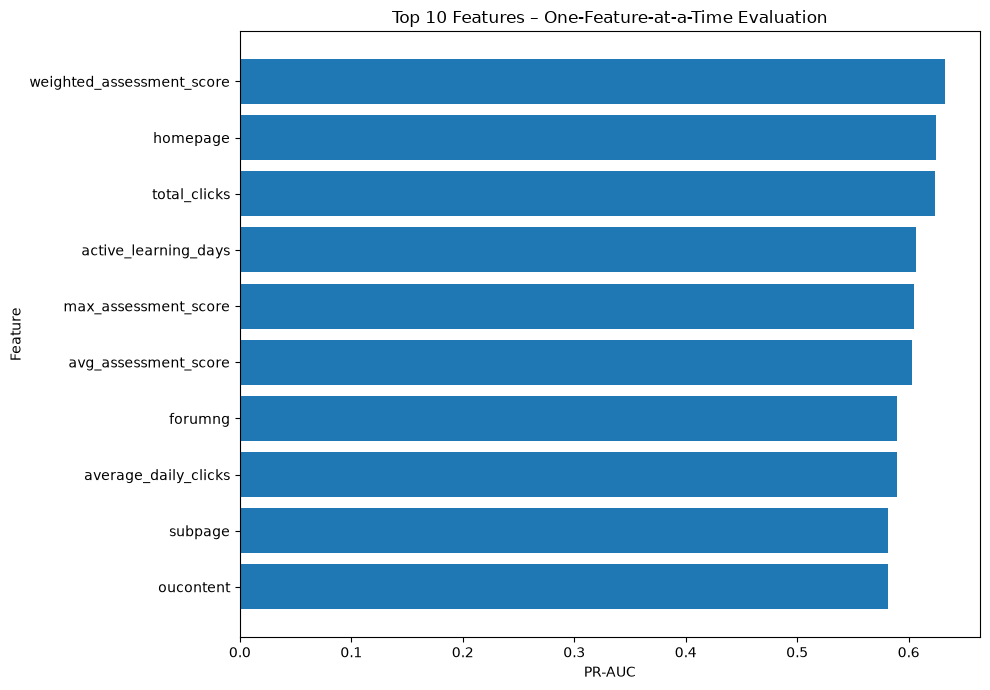

In [63]:
plot_df = (
    single_feature_results_df
    .head(10)
    .sort_values("pr_auc")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["pr_auc"]
)

plt.xlabel("PR-AUC")
plt.ylabel("Feature")
plt.title(
    "Top 10 Features – One-Feature-at-a-Time Evaluation"
)

plt.tight_layout()
plt.show()

Compare with Pearson correlation

In [64]:
comparison_df = single_feature_results_df.merge(
    correlation_df.rename(
        "pearson_correlation"
    ),
    left_on="feature",
    right_index=True,
    how="left"
)

comparison_df = comparison_df[
    [
        "feature",
        "pearson_correlation",
        "pr_auc",
        "roc_auc",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "fp",
        "fn"
    ]
]

display(comparison_df.head(15))

,feature,pearson_correlation,pr_auc,roc_auc,balanced_accuracy,precision,recall,f1,fp,fn
0,weighted_assessment_score,-0.239883,0.632383,0.806501,0.747306,0.560077,0.767717,0.647661,919,354
1,homepage,-0.160127,0.624109,0.743156,0.664273,0.455075,0.717848,0.557026,1310,430
2,total_clicks,-0.180901,0.624028,0.737675,0.656405,0.448664,0.705381,0.548469,1321,449
3,active_learning_days,-0.257157,0.606657,0.752194,0.664468,0.444018,0.759843,0.560503,1450,366
4,max_assessment_score,-0.273943,0.604356,0.791959,0.737621,0.582203,0.704068,0.637363,770,451
5,avg_assessment_score,-0.246256,0.603047,0.786720,0.726135,0.544385,0.728346,0.623070,929,414
6,forumng,-0.129011,0.589505,0.728145,0.651581,0.439791,0.716535,0.545046,1391,432
7,average_daily_clicks,-0.071456,0.589191,0.684618,0.634793,0.450269,0.603018,0.515568,1122,605
8,subpage,-0.125049,0.581802,0.704506,0.643178,0.445934,0.654856,0.530569,1240,526
9,oucontent,-0.152262,0.581166,0.709050,0.623487,0.399123,0.776247,0.527184,1781,341


### Feature Group Ablation

Define feature groups

Group 1 — Student Profile

In [65]:
student_profile_features = [
    "num_of_prev_attempts",
    "studied_credits",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability"
]

Group 2 — Course Context

In [66]:
course_context_features = [
    "code_module",
    "code_presentation",
    "course_duration",
    "number_of_early_assessments",
    "average_early_assessment_weight",
    "early_assessment_workload"
]

Group 3 — Registration

In [67]:
registration_features = [
    "date_registration",
    "registration_days_before_start",
    "late_registration"
]

Group 4 — Assessment Behavior

In [68]:
assessment_features = [
    "assessment_count",
    "avg_assessment_score",
    "max_assessment_score",
    "min_assessment_score",
    "weighted_assessment_score",
    "late_submission_count"
]

Group 5 — VLE Engagement

In [69]:
vle_features = [
    "total_clicks",
    "active_learning_days",
    "distinct_resources",
    "resource_diversity",
    "average_daily_clicks",
    "dataplus",
    "dualpane",
    "externalquiz",
    "forumng",
    "glossary",
    "homepage",
    "htmlactivity",
    "oucollaborate",
    "oucontent",
    "ouelluminate",
    "ouwiki",
    "page",
    "questionnaire",
    "quiz",
    "repeatactivity",
    "resource",
    "sharedsubpage",
    "subpage",
    "url"
]

Put the groups into one dictionary

In [70]:
feature_groups = {
    "Student Profile": student_profile_features,
    "Course Context": course_context_features,
    "Registration": registration_features,
    "Assessment Behavior": assessment_features,
    "VLE Engagement": vle_features
}

for group, features in feature_groups.items():
    print(f"{group}: {len(features)} features")

Student Profile: 8 features
Course Context: 6 features
Registration: 3 features
Assessment Behavior: 6 features
VLE Engagement: 24 features


Verify that every feature is assigned

In [71]:
grouped_features = [
    feature
    for features in feature_groups.values()
    for feature in features
]

print("Total features in X_train:", len(raw_features))
print("Features assigned to groups:", len(grouped_features))

print(
    "All features assigned:",
    set(raw_features) == set(grouped_features)
)

Total features in X_train: 47
Features assigned to groups: 47
All features assigned: True


Create a function to get columns for a group

In [72]:
def get_group_indexes(features):

    indexes = []

    for feature in features:

        if feature not in encoded_column_index:
            print(
                f"Warning: {feature} not found"
            )
            continue

        indexes.extend(
            encoded_column_index[feature]
        )

    return sorted(set(indexes))

Test one group

In [73]:
#Assessment Behavior
assessment_indexes = get_group_indexes(
    assessment_features
)

print("Assessment encoded columns:")
print(assessment_indexes)

print(
    "Number of encoded columns:",
    len(assessment_indexes)
)

Assessment encoded columns:
[2, 3, 4, 5, 6, 7]
Number of encoded columns: 6


Train using ONLY Assessment features

In [74]:
X_train_assessment = X_train[
    :,
    assessment_indexes
]

X_eval_assessment = X_eval[
    :,
    assessment_indexes
]

print(
    "X_train assessment shape:",
    X_train_assessment.shape
)

print(
    "X_eval assessment shape:",
    X_eval_assessment.shape
)

X_train assessment shape: (22815, 6)
X_eval assessment shape: (4889, 6)


In [75]:
assessment_model = create_hgb_model()

assessment_model.fit(
    X_train_assessment,
    y_train,
    sample_weight=sample_weights_train
)

assessment_probabilities = (
    assessment_model
    .predict_proba(X_eval_assessment)[:, 1]
)

assessment_result = calculate_metrics(
    y_eval,
    assessment_probabilities
)

assessment_result["feature_group"] = (
    "Assessment Behavior"
)

assessment_result

{'roc_auc': 0.8341394547078347,
 'pr_auc': 0.6547504156694302,
 'balanced_accuracy': 0.7838071782631926,
 'precision': 0.6176772867420349,
 'recall': 0.7887139107611548,
 'f1': 0.6927953890489914,
 'fp': 744,
 'fn': 322,
 'feature_group': 'Assessment Behavior'}

Create Function

In [76]:
def evaluate_feature_group(group_name, features):

    indexes = get_group_indexes(features)

    X_train_group = X_train[:, indexes]
    X_eval_group = X_eval[:, indexes]

    model = create_hgb_model()

    model.fit(
        X_train_group,
        y_train,
        sample_weight=sample_weights_train
    )

    probabilities = (
        model.predict_proba(
            X_eval_group
        )[:, 1]
    )

    metrics = calculate_metrics(
        y_eval,
        probabilities
    )

    metrics["feature_group"] = group_name
    metrics["raw_feature_count"] = len(features)
    metrics["encoded_feature_count"] = len(indexes)

    return metrics

In [77]:
group_results = []

for group_name, features in feature_groups.items():

    print(
        f"Evaluating group: {group_name}"
    )

    result = evaluate_feature_group(
        group_name,
        features
    )

    group_results.append(result)

Evaluating group: Student Profile
Evaluating group: Course Context
Evaluating group: Registration
Evaluating group: Assessment Behavior
Evaluating group: VLE Engagement


In [78]:
group_results_df = pd.DataFrame(
    group_results
)

group_results_df = (
    group_results_df
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(group_results_df)

,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn,feature_group,raw_feature_count,encoded_feature_count
0,0.807845,0.691684,0.729143,0.547596,0.732283,0.626614,922,408,VLE Engagement,24,24
1,0.834139,0.654750,0.783807,0.617677,0.788714,0.692795,744,322,Assessment Behavior,6,6
2,0.654304,0.465924,0.583801,0.365385,0.785433,0.498750,2079,327,Student Profile,8,37
3,0.626593,0.403716,0.559318,0.342131,0.918635,0.498575,2692,124,Course Context,6,15
4,0.584350,0.384882,0.518497,0.320384,0.941601,0.478094,3044,89,Registration,3,3


Plot group performance

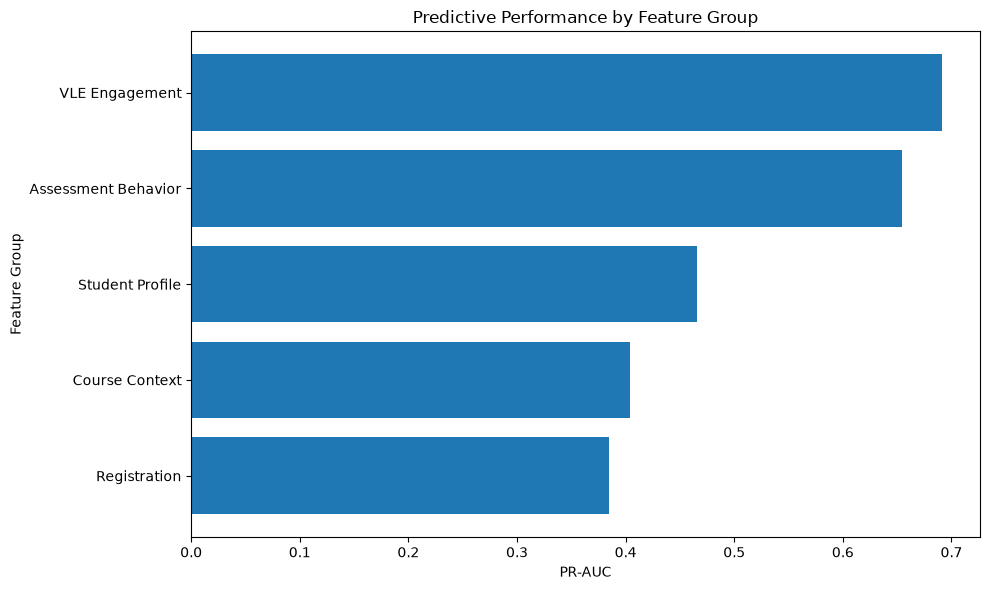

In [79]:
plot_group_df = (
    group_results_df
    .sort_values("pr_auc")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_group_df["feature_group"],
    plot_group_df["pr_auc"]
)

plt.xlabel("PR-AUC")
plt.ylabel("Feature Group")
plt.title(
    "Predictive Performance by Feature Group"
)

plt.tight_layout()
plt.show()

Experiment: Remove one group

In [80]:
#Establish the full-model baseline

full_model = create_hgb_model()

full_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

full_probabilities = (
    full_model.predict_proba(X_eval)[:, 1]
)

full_result = calculate_metrics(
    y_eval,
    full_probabilities
)

full_result

{'roc_auc': 0.8736812291108486,
 'pr_auc': 0.8034306201036722,
 'balanced_accuracy': 0.8016817595051733,
 'precision': 0.6664798206278026,
 'recall': 0.7801837270341208,
 'f1': 0.718863361547763,
 'fp': 595,
 'fn': 335}

In [81]:
full_pr_auc = full_result["pr_auc"]

print(
    "Full model PR-AUC:",
    round(full_pr_auc, 4)
)

Full model PR-AUC: 0.8034


Create the group-removal experiment

In [82]:
ablation_results = []

all_indexes = set(range(X_train.shape[1]))

for group_name, features in feature_groups.items():

    group_indexes = set(
        get_group_indexes(features)
    )

    remaining_indexes = sorted(
        all_indexes - group_indexes
    )

    X_train_remaining = X_train[
        :,
        remaining_indexes
    ]

    X_eval_remaining = X_eval[
        :,
        remaining_indexes
    ]

    model = create_hgb_model()

    model.fit(
        X_train_remaining,
        y_train,
        sample_weight=sample_weights_train
    )

    probabilities = (
        model.predict_proba(
            X_eval_remaining
        )[:, 1]
    )

    metrics = calculate_metrics(
        y_eval,
        probabilities
    )

    metrics["removed_group"] = group_name

    metrics["pr_auc_drop"] = (
        full_pr_auc - metrics["pr_auc"]
    )

    metrics["recall_drop"] = (
        full_result["recall"] -
        metrics["recall"]
    )

    ablation_results.append(metrics)

Display ablation results

In [83]:
ablation_results_df = pd.DataFrame(
    ablation_results
)

ablation_results_df = (
    ablation_results_df
    .sort_values(
        "pr_auc_drop",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ablation_results_df)

,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn,removed_group,pr_auc_drop,recall_drop
0,0.841211,0.762297,0.760456,0.590214,0.759843,0.664372,804,366,Assessment Behavior,0.041133,0.020341
1,0.871244,0.790034,0.801738,0.668546,0.778215,0.719224,588,338,Student Profile,0.013397,0.001969
2,0.866338,0.792474,0.792365,0.651524,0.771654,0.706518,629,348,Course Context,0.010956,0.008530
3,0.871250,0.796418,0.803638,0.674061,0.777559,0.722121,573,339,VLE Engagement,0.007013,0.002625
4,0.876156,0.804678,0.800487,0.666667,0.776903,0.717576,592,340,Registration,-0.001247,0.003281


Feature Group Ablation

Student Profile

Course Context

Registration

Assessment Behavior

VLE Engagement

Test each group individually

First create this function:

In [84]:
def evaluate_feature_group(group_name, features):

    indexes = get_group_indexes(features)

    X_train_group = X_train[:, indexes]
    X_eval_group = X_eval[:, indexes]

    model = create_hgb_model()

    model.fit(
        X_train_group,
        y_train,
        sample_weight=sample_weights_train
    )

    probabilities = model.predict_proba(
        X_eval_group
    )[:, 1]

    metrics = calculate_metrics(
        y_eval,
        probabilities
    )

    metrics["feature_group"] = group_name
    metrics["raw_feature_count"] = len(features)
    metrics["encoded_feature_count"] = len(indexes)

    return metrics

Run all 5 groups

In [85]:
group_results = []

for group_name, features in feature_groups.items():

    print(f"Evaluating: {group_name}")

    result = evaluate_feature_group(
        group_name,
        features
    )

    group_results.append(result)

Evaluating: Student Profile
Evaluating: Course Context
Evaluating: Registration
Evaluating: Assessment Behavior
Evaluating: VLE Engagement


Create the results table

In [86]:
group_results_df = pd.DataFrame(group_results)

group_results_df = (
    group_results_df
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(group_results_df)

,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn,feature_group,raw_feature_count,encoded_feature_count
0,0.807845,0.691684,0.729143,0.547596,0.732283,0.626614,922,408,VLE Engagement,24,24
1,0.834139,0.654750,0.783807,0.617677,0.788714,0.692795,744,322,Assessment Behavior,6,6
2,0.654304,0.465924,0.583801,0.365385,0.785433,0.498750,2079,327,Student Profile,8,37
3,0.626593,0.403716,0.559318,0.342131,0.918635,0.498575,2692,124,Course Context,6,15
4,0.584350,0.384882,0.518497,0.320384,0.941601,0.478094,3044,89,Registration,3,3


Plot group PR-AUC

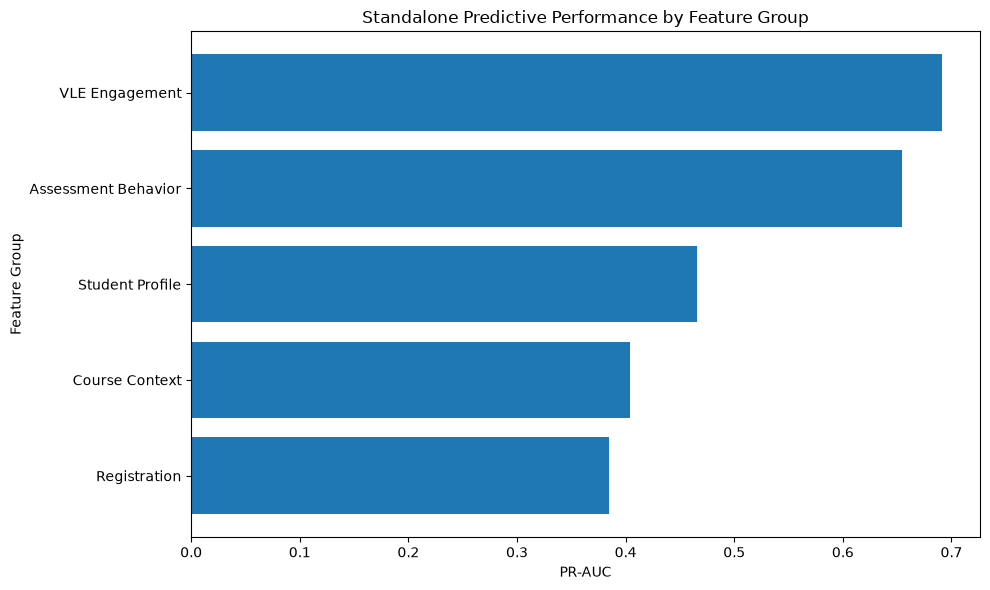

In [87]:
plot_group_df = (
    group_results_df
    .sort_values("pr_auc")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_group_df["feature_group"],
    plot_group_df["pr_auc"]
)

plt.xlabel("PR-AUC")
plt.ylabel("Feature Group")
plt.title("Standalone Predictive Performance by Feature Group")

plt.tight_layout()
plt.show()

Now build the full model

In [88]:
full_model = create_hgb_model()

full_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

full_probabilities = (
    full_model.predict_proba(X_eval)[:, 1]
)

full_result = calculate_metrics(
    y_eval,
    full_probabilities
)

print("Full model results:")
display(pd.DataFrame([full_result]))

Full model results:


,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn
0,0.873681,0.803431,0.801682,0.66648,0.780184,0.718863,595,335


In [89]:
full_pr_auc = full_result["pr_auc"]
full_recall = full_result["recall"]

print("Full model PR-AUC:", round(full_pr_auc, 4))
print("Full model Recall:", round(full_recall, 4))

Full model PR-AUC: 0.8034
Full model Recall: 0.7802


Remove one group at a time

In [90]:
ablation_results = []

all_indexes = set(range(X_train.shape[1]))

for group_name, features in feature_groups.items():

    print(f"Removing: {group_name}")

    group_indexes = set(
        get_group_indexes(features)
    )

    remaining_indexes = sorted(
        all_indexes - group_indexes
    )

    X_train_remaining = X_train[:, remaining_indexes]
    X_eval_remaining = X_eval[:, remaining_indexes]

    model = create_hgb_model()

    model.fit(
        X_train_remaining,
        y_train,
        sample_weight=sample_weights_train
    )

    probabilities = (
        model.predict_proba(
            X_eval_remaining
        )[:, 1]
    )

    metrics = calculate_metrics(
        y_eval,
        probabilities
    )

    metrics["removed_group"] = group_name

    metrics["pr_auc_drop"] = (
        full_result["pr_auc"] -
        metrics["pr_auc"]
    )

    metrics["recall_drop"] = (
        full_result["recall"] -
        metrics["recall"]
    )

    ablation_results.append(metrics)

Removing: Student Profile
Removing: Course Context
Removing: Registration
Removing: Assessment Behavior
Removing: VLE Engagement


View the ablation results

In [91]:
ablation_results_df = pd.DataFrame(
    ablation_results
)

ablation_results_df = (
    ablation_results_df
    .sort_values(
        "pr_auc_drop",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ablation_results_df)

,roc_auc,pr_auc,balanced_accuracy,precision,recall,f1,fp,fn,removed_group,pr_auc_drop,recall_drop
0,0.841211,0.762297,0.760456,0.590214,0.759843,0.664372,804,366,Assessment Behavior,0.041133,0.020341
1,0.871244,0.790034,0.801738,0.668546,0.778215,0.719224,588,338,Student Profile,0.013397,0.001969
2,0.866338,0.792474,0.792365,0.651524,0.771654,0.706518,629,348,Course Context,0.010956,0.008530
3,0.871250,0.796418,0.803638,0.674061,0.777559,0.722121,573,339,VLE Engagement,0.007013,0.002625
4,0.876156,0.804678,0.800487,0.666667,0.776903,0.717576,592,340,Registration,-0.001247,0.003281


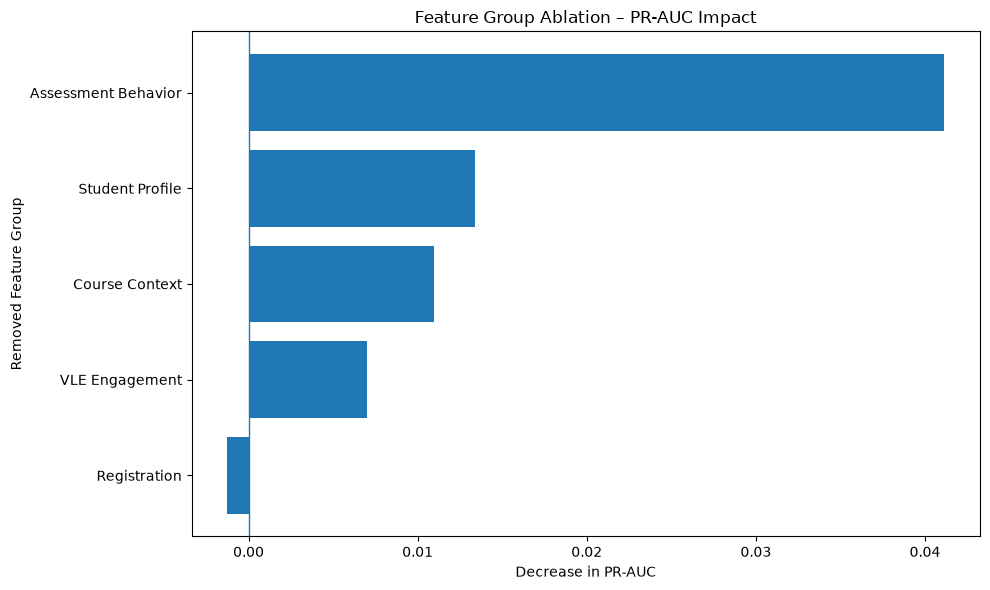

In [92]:
plot_ablation = (
    ablation_results_df
    .sort_values("pr_auc_drop")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_ablation["removed_group"],
    plot_ablation["pr_auc_drop"]
)

plt.xlabel("Decrease in PR-AUC")
plt.ylabel("Removed Feature Group")
plt.title("Feature Group Ablation – PR-AUC Impact")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

## Feature Group Analysis – Findings

The standalone group analysis showed that VLE Engagement achieved the
highest PR-AUC when used independently, followed by Assessment Behavior.

However, the ablation analysis produced a different and more informative
finding. Removing Assessment Behavior caused the largest decrease in
evaluation PR-AUC (0.0411), indicating that assessment-related features
provide the greatest unique contribution to the complete model.

Removing VLE Engagement resulted in a smaller PR-AUC decrease of 0.0070.
This suggests that although VLE activity is highly predictive by itself,
some of its information may overlap with information contained in other
feature groups.

Student Profile and Course Context produced moderate effects when removed.

Removing Registration features resulted in a very small improvement in
PR-AUC (-0.00125 PR-AUC drop). This suggests that Registration features
provide little additional unique predictive information in the current
feature set.

Overall, Assessment Behavior appears to be the most uniquely valuable
feature group, while VLE Engagement provides strong standalone predictive
signal.

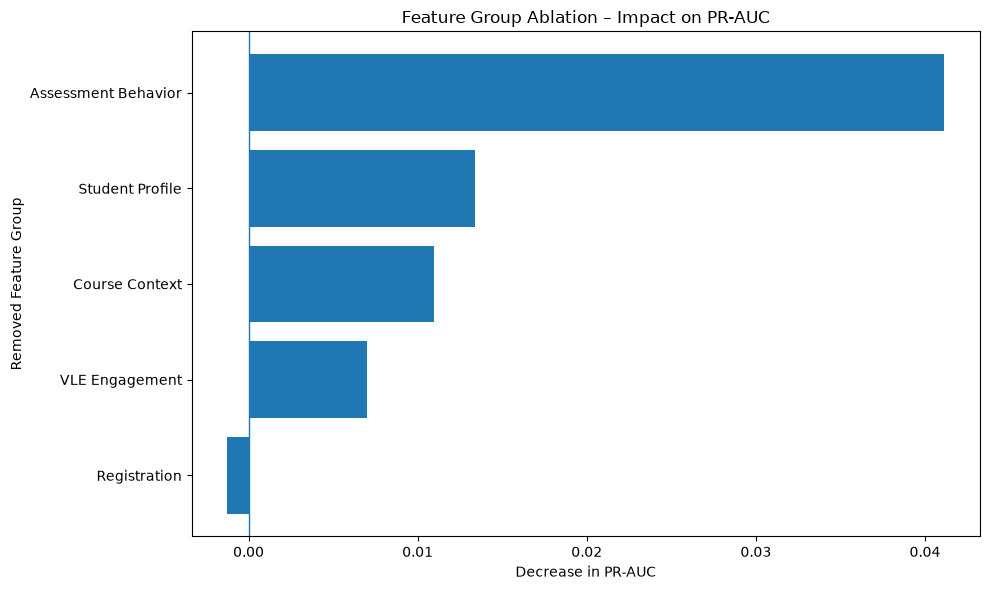

In [93]:
plot_ablation = (
    ablation_results_df
    .sort_values("pr_auc_drop")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_ablation["removed_group"],
    plot_ablation["pr_auc_drop"]
)

plt.xlabel("Decrease in PR-AUC")
plt.ylabel("Removed Feature Group")
plt.title(
    "Feature Group Ablation – Impact on PR-AUC"
)

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()